Install Required Libraries

In [ ]:
!pip install -q transformers datasets scikit-learn

Load and Preprocess Dreaddit Dataset

In [ ]:
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split

# Load Dreaddit dataset with only relevant columns
df = pd.read_csv('/content/dreaddit_train_cleaned.csv')[['text', 'label']]

# Perform stratified Train/Val/Test split
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# Convert to Hugging Face Datasets
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

Counterfactual Data Augmentation

In [ ]:
# Generate counterfactual gender-swapped text for fairness augmentation

def generate_counterfactual(text):
    swaps = {
        " he ": " she ", " she ": " he ",
        " He ": " She ", " She ": " He ",
        " his ": " her ", " her ": " his ",
        " His ": " Her ", " Her ": " His ",
        " him ": " her ", " her ": " him ",
        " man ": " woman ", " woman ": " man ",
        " boy ": " girl ", " girl ": " boy "
    }
    for k, v in swaps.items():
        text = text.replace(k, v)
    return text

# Apply counterfactuals to the training data
cf_train_df = train_df.copy()
cf_train_df["text"] = cf_train_df["text"].apply(generate_counterfactual)
cf_train_df["label"] = train_df["label"]

# Combine original + counterfactuals
augmented_train_df = pd.concat([train_df, cf_train_df]).reset_index(drop=True)

# Save to CSV to reuse later
augmented_train_df.to_csv("dreaddit_train_augmented.csv", index=False)

Load Augmented Dataset and Tokenize


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load the previously saved augmented dataset
augmented_train_df = pd.read_csv("dreaddit_train_augmented.csv")

# Convert to Hugging Face Dataset format
train_ds = Dataset.from_pandas(augmented_train_df)
val_ds = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

# Load tokenizer
model_id = "facebook/bart-large"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Define tokenization function
def preprocess(example):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=128)

# Tokenize all datasets
train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

# Load classification model
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2)

Define Metrics and Training Arguments

In [ ]:
import numpy as np
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score

# Define evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple): logits = logits[0]
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

# Set training parameters
training_args = TrainingArguments(
    output_dir="./bart_dreaddit_output",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=2,
    learning_rate=2e-5,
    logging_steps=50,
    report_to="none"
)

Train the Model

In [ ]:
# Setup Trainer and train the model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)

trainer.train()

Map:   0%|          | 0/2256 [00:00<?, ? examples/s]

Map:   0%|          | 0/282 [00:00<?, ? examples/s]

Map:   0%|          | 0/283 [00:00<?, ? examples/s]

Some weights of BartForSequenceClassification were not initialized from the model checkpoint at facebook/bart-large and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-50-63880bc2e32b>:61: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
50,0.703000
100,0.604900
150,0.594400
200,0.588700
250,0.519200
300,0.555100
350,0.477200
400,0.538900
450,0.537600
500,0.598000


/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:393: UserWarning: Some non-default generation parameters are set in the model config. These should go into either a) `model.generation_config` (as opposed to `model.config`); OR b) a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model).This warning will become an exception in the future.
Non-default generation parameters: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:393: UserWarning: Some non-default generation parameters are set in the model config. These should go into either a) `model.generation_config` (as opposed to `model.config`); OR b) a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model).This warning 

TrainOutput(global_step=1128, training_loss=0.47218764631460747, metrics={'train_runtime': 194.2963, 'train_samples_per_second': 23.222, 'train_steps_per_second': 5.806, 'total_flos': 1225891189997568.0, 'train_loss': 0.47218764631460747, 'epoch': 2.0})

Evaluate Model on Test Set

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions on test set
preds = trainer.predict(test_ds)
logits = preds.predictions[0] if isinstance(preds.predictions, tuple) else preds.predictions
y_pred = np.argmax(logits, axis=1)
y_true = test_ds["label"]

# Print classification report and confusion matrix
print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81       134
           1       0.80      0.91      0.85       149

    accuracy                           0.83       283
   macro avg       0.84      0.83      0.83       283
weighted avg       0.84      0.83      0.83       283

[[100  34]
 [ 14 135]]


Install and Import Fairness Metrics

In [ ]:
# Install fairlearn and import fairness metric functions
!pip install fairlearn --quiet

from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    MetricFrame
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 2.8 MB/s eta 0:00:00


Prepare Binary Protected Attributes

In [ ]:
# Binary encoding for gender: 1 = male, 0 = others
test_df["gender_binary"] = test_df["gender"].str.lower().apply(lambda x: 1 if x in ["male", "m"] else 0)

# Binary encoding for age group: 1 = young (18–24, 25–34), 0 = others
test_df["age_binary"] = test_df["age_group"].apply(lambda x: 1 if x in ["18-24", "25-34"] else 0)

Fairness Evaluation and Visualization

Running Fairness Evaluation...
Binary Fairness Metrics:

Attribute: gender_binary
  → Demographic Parity Difference (DPD): 0.0165
  → Equalized Odds Difference (EOD):    0.0565

Attribute: age_binary
  → Demographic Parity Difference (DPD): 0.0915
  → Equalized Odds Difference (EOD):    0.0265

Performance by Protected Groups:

Protected Feature: gender_binary
               accuracy  macro_f1
gender_binary                     
0              0.8602    0.8561
1              0.7924    0.7845

Protected Feature: age_binary
            accuracy  macro_f1
age_binary                    
0           0.8407    0.8312
1           0.8246    0.8199


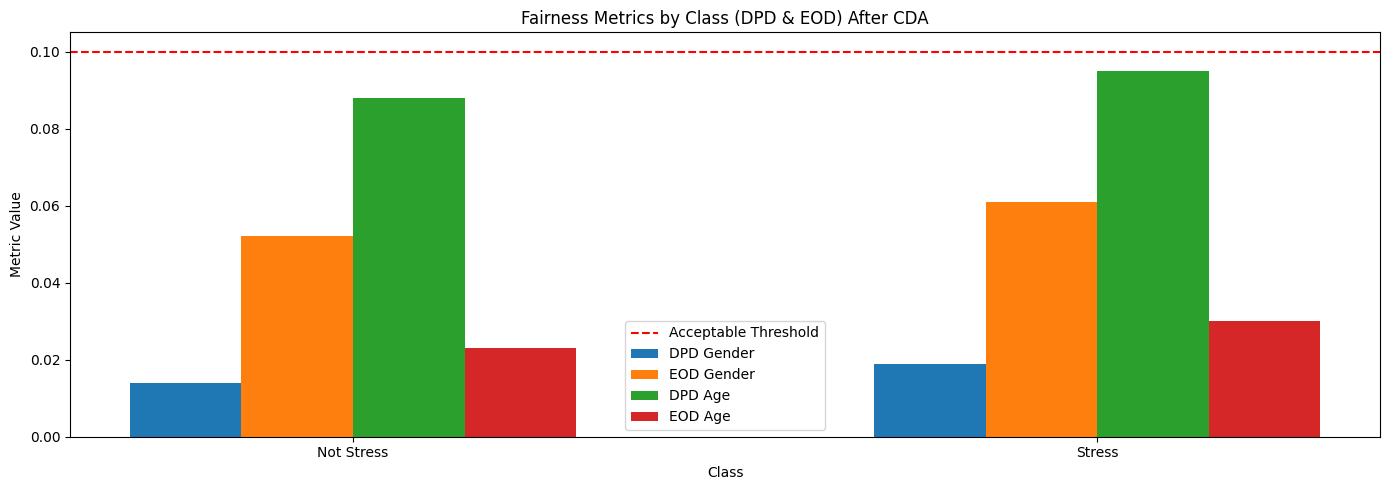

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert predicted and true labels to NumPy arrays
y_true = test_df["true"].to_numpy()
y_pred = test_df["prediction"].to_numpy()

print("Running Fairness Evaluation...")
print("Binary Fairness Metrics:")

# Calculate DPD and EOD for gender and age
for attr in ["gender_binary", "age_binary"]:
    dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=test_df[attr])
    eod = equalized_odds_difference(y_true, y_pred, sensitive_features=test_df[attr])

    print(f"\nAttribute: {attr}")
    print(f"  → Demographic Parity Difference (DPD): {dpd:.4f}")
    print(f"  → Equalized Odds Difference (EOD):    {eod:.4f}")

# Group performance metrics
print("\nPerformance by Protected Groups:")
metrics = {
    "accuracy": lambda y_true, y_pred: (y_true == y_pred).mean(),
    "macro_f1": lambda y_true, y_pred: classification_report(
        y_true, y_pred, output_dict=True, zero_division=0)["macro avg"]["f1-score"]
}

# Report metrics by group
for attr in ["gender_binary", "age_binary"]:
    print(f"\nProtected Feature: {attr}")
    mf = MetricFrame(
        metrics=metrics,
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=test_df[attr]
    )
    print(mf.by_group)

# Fairness bar plot (DPD & EOD by class)
class_names = ['Not Stress', 'Stress']
metrics_data = []

for class_label, class_name in enumerate(class_names):
    y_true_bin = (y_true == class_label).astype(int)
    y_pred_bin = (y_pred == class_label).astype(int)

    dpd_gender = demographic_parity_difference(y_true_bin, y_pred_bin, sensitive_features=test_df["gender_binary"])
    eod_gender = equalized_odds_difference(y_true_bin, y_pred_bin, sensitive_features=test_df["gender_binary"])

    dpd_age = demographic_parity_difference(y_true_bin, y_pred_bin, sensitive_features=test_df["age_binary"])
    eod_age = equalized_odds_difference(y_true_bin, y_pred_bin, sensitive_features=test_df["age_binary"])

    metrics_data.extend([
        {'Class': class_name, 'Metric': 'DPD Gender', 'Value': dpd_gender},
        {'Class': class_name, 'Metric': 'EOD Gender', 'Value': eod_gender},
        {'Class': class_name, 'Metric': 'DPD Age', 'Value': dpd_age},
        {'Class': class_name, 'Metric': 'EOD Age', 'Value': eod_age},
    ])

# Plot fairness metrics
metrics_df = pd.DataFrame(metrics_data)
plt.figure(figsize=(12, 5))
sns.barplot(data=metrics_df, x='Class', y='Value', hue='Metric')
plt.title("Fairness Metrics by Class (DPD & EOD)")
plt.axhline(0.1, color='red', linestyle='--', label='Acceptable Threshold')
plt.ylabel("Metric Value")
plt.tight_layout()
plt.legend()
plt.show()